# BUSINESS DATA ANALYTICS APPLIED LAB 2: RISK MANAGEMENT & OSH ANALYTICS
Un conglomerado de 150 empresas está alarmado por el aumento en los reportes de accidentes laborales. El costo de las incapacidades y el impacto humano están afectando la productividad global. La gerencia no solo necesita saber cuántos accidentes ocurren, sino que requiere identificar patrones de riesgo para implementar una estrategia de prevención. Su misión como analista de datos consiste en aplicar la metodología CRISP-DM para consolidar fuentes de datos dispersas, generar evidencia visual sobre los factores de riesgo (jornada, capacitación y sector) y proponer reglas de negocio preventivas.

_Actualizado: 16/02/2026_
_ebuitragob@ucentral.edu.co_

## Carga y transformación datos

In [44]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
# Paso 1: Carga y Preparación de Datos (Data Understanding)
df_trabajadores = pd.read_csv('trabajadores.csv')
df_empresas = pd.read_csv('empresas.csv')
df_accidentes = pd.read_csv('accidentes.csv')


In [46]:
# Paso 2: Consolidación de Información (Data Preparation / Triple Join)
# Unimos trabajadores con empresas
df_merge = pd.merge(df_trabajadores, df_empresas, left_on='empresa', right_on='id_empresa')

# Unir con accidentes (Left join para no perder a quienes NO tuvieron accidentes)
df_final = pd.merge(df_merge, df_accidentes, on='id_trabajador', how='left')

# Crear variable binaria: 1 si hubo accidente, 0 si no
df_final['incidente'] = df_final['id_accidente'].notnull().astype(int)

## Visualización

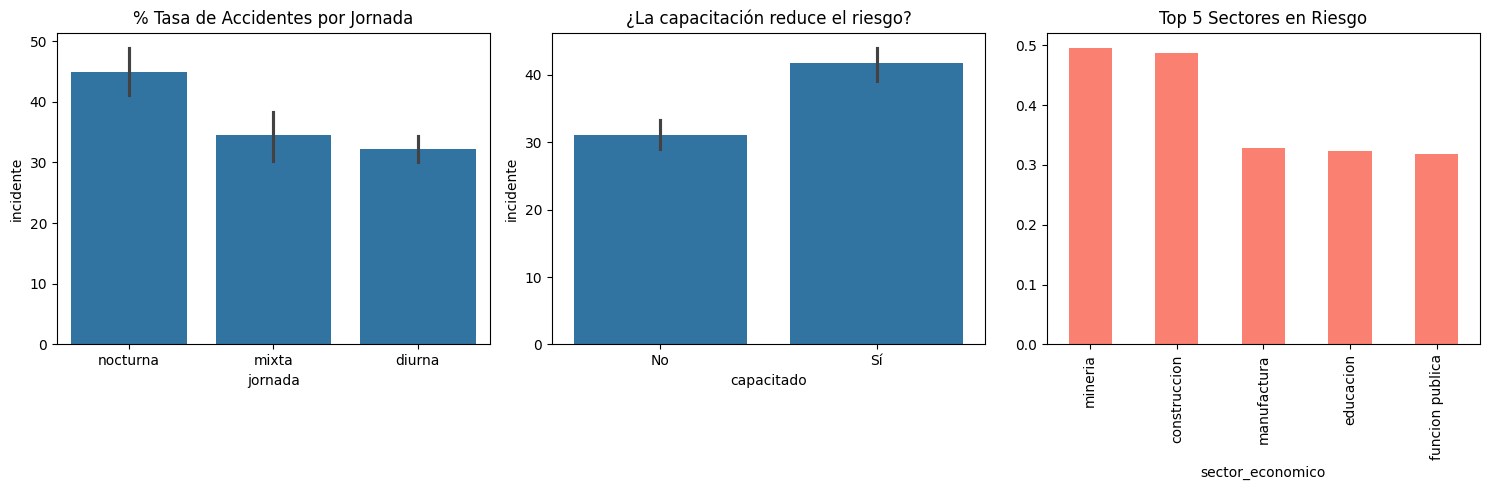

In [6]:
# Paso 3: Modelado Descriptivo (Visualización de Evidencia)
plt.figure(figsize=(15, 5))

# Gráfico 1: Riesgo por Jornada
plt.subplot(1, 3, 1)
sns.barplot(data=df_final, x='jornada', y='incidente', estimator=lambda x: sum(x)/len(x)*100)
plt.title('% Tasa de Accidentes por Jornada')

# Gráfico 2: Impacto de la Capacitación
plt.subplot(1, 3, 2)
sns.barplot(data=df_final, x='capacitado', y='incidente', estimator=lambda x: sum(x)/len(x)*100)
plt.xticks([0, 1], ['No', 'Sí'])
plt.title('¿La capacitación reduce el riesgo?')

# Gráfico 3: Sectores más críticos (Top 5)
plt.subplot(1, 3, 3)
df_final.groupby('sector_economico')['incidente'].mean().sort_values(ascending=False).head(5).plot(kind='bar', color='salmon')
plt.title('Top 5 Sectores en Riesgo')

plt.tight_layout()
plt.show()

In [7]:
# --- SECCIÓN DE EXPLORACIÓN AUTÓNOMA ---
# INSTRUCCIÓN: El estudiante debe generar otros gráficos que
# considere necesarios para profundizar en su análisis.
# Sugerencia: Explore la relación entre 'antiguedad', 'nivel_educativo' o
# 'sistema_gestion' respecto a la variable 'incidente'.

## Análisis

ITERACIÓN 1

¿La implementación de un sistema de gestión está asociada con una menor tasa de accidentes?

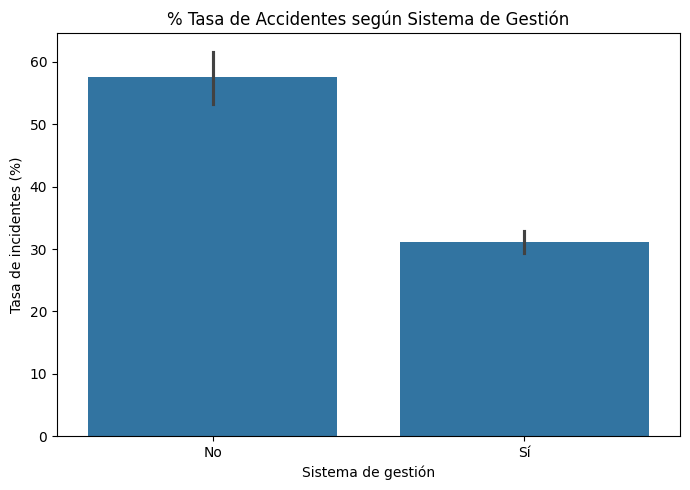

In [8]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df_final,
    x='sistema_gestion',
    y='incidente',
    estimator=lambda x: sum(x)/len(x)*100
)

plt.xticks([0, 1], ['No', 'Sí'])
plt.title('% Tasa de Accidentes según Sistema de Gestión')
plt.xlabel('Sistema de gestión')
plt.ylabel('Tasa de incidentes (%)')
plt.tight_layout()
plt.show()

¿Los trabajadores con menor o mayor antigüedad presentan mayor riesgo de accidente?

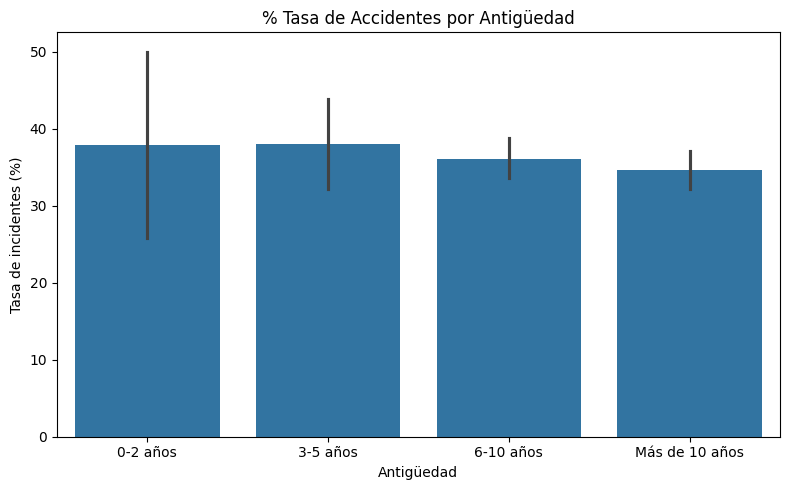

In [9]:
# Crear rangos de antigüedad
df_final['rango_antiguedad'] = pd.cut(
    df_final['antiguedad'],
    bins=[0, 2, 5, 10, float('inf')],
    labels=['0-2 años', '3-5 años', '6-10 años', 'Más de 10 años']
)

# Gráfico
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_final,
    x='rango_antiguedad',
    y='incidente',
    estimator=lambda x: sum(x)/len(x)*100
)

plt.title('% Tasa de Accidentes por Antigüedad')
plt.xlabel('Antigüedad')
plt.ylabel('Tasa de incidentes (%)')
plt.tight_layout()
plt.show()

¿Existe diferencia en la tasa de incidentes según el nivel educativo?

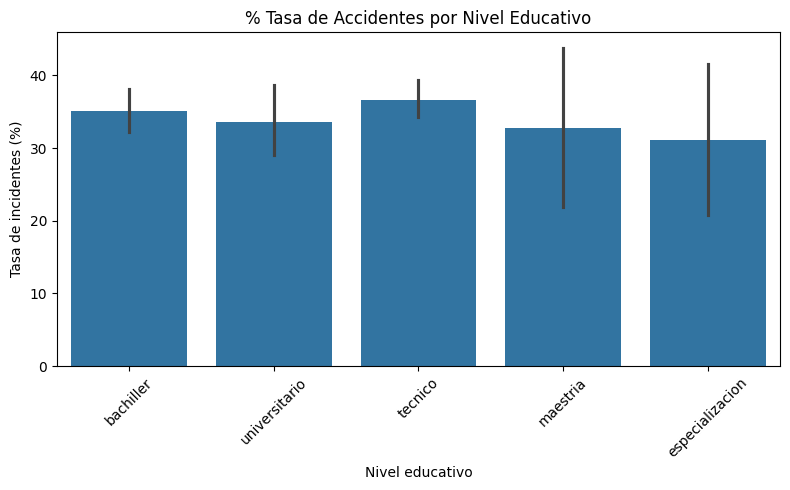

In [10]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_final,
    x='nivel_educativo',
    y='incidente',
    estimator=lambda x: sum(x)/len(x)*100
)

plt.title('% Tasa de Accidentes por Nivel Educativo')
plt.xlabel('Nivel educativo')
plt.ylabel('Tasa de incidentes (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

¿La capacitación se comporta igual dentro de cada jornada?

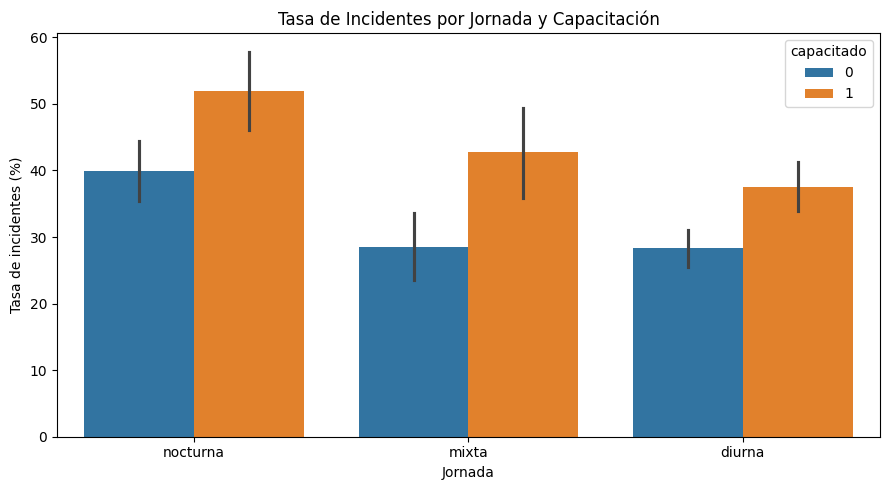

In [11]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=df_final,
    x='jornada',
    y='incidente',
    hue='capacitado',
    estimator=lambda x: sum(x)/len(x)*100
)

plt.title('Tasa de Incidentes por Jornada y Capacitación')
plt.xlabel('Jornada')
plt.ylabel('Tasa de incidentes (%)')
plt.tight_layout()
plt.show()

¿La capacitación tiene el mismo comportamiento en todos los sectores?

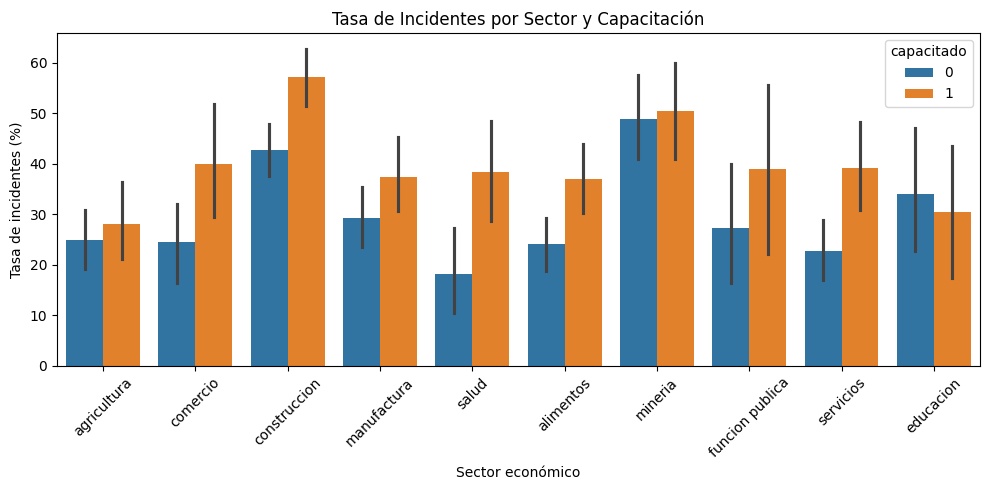

In [12]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_final,
    x='sector_economico',
    y='incidente',
    hue='capacitado',
    estimator=lambda x: sum(x)/len(x)*100
)

plt.title('Tasa de Incidentes por Sector y Capacitación')
plt.xlabel('Sector económico')
plt.ylabel('Tasa de incidentes (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
top_5_sectores = (
    df_final.groupby('sector_economico')['incidente']
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

In [14]:
df_top5 = df_final[df_final['sector_economico'].isin(top_5_sectores)]

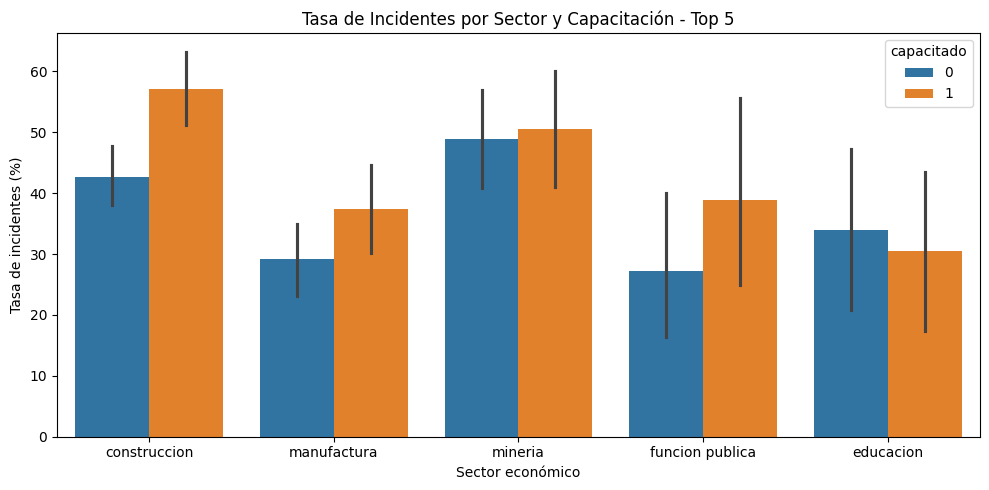

In [15]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_top5,
    x='sector_economico',
    y='incidente',
    hue='capacitado',
    estimator=lambda x: sum(x)/len(x)*100
)

plt.title('Tasa de Incidentes por Sector y Capacitación - Top 5')
plt.xlabel('Sector económico')
plt.ylabel('Tasa de incidentes (%)')
plt.tight_layout()
plt.show()

ITERACIÓN 2

¿la jornada nocturna presenta mayor riesgo incluso dentro de los diferentes sectores económicos?

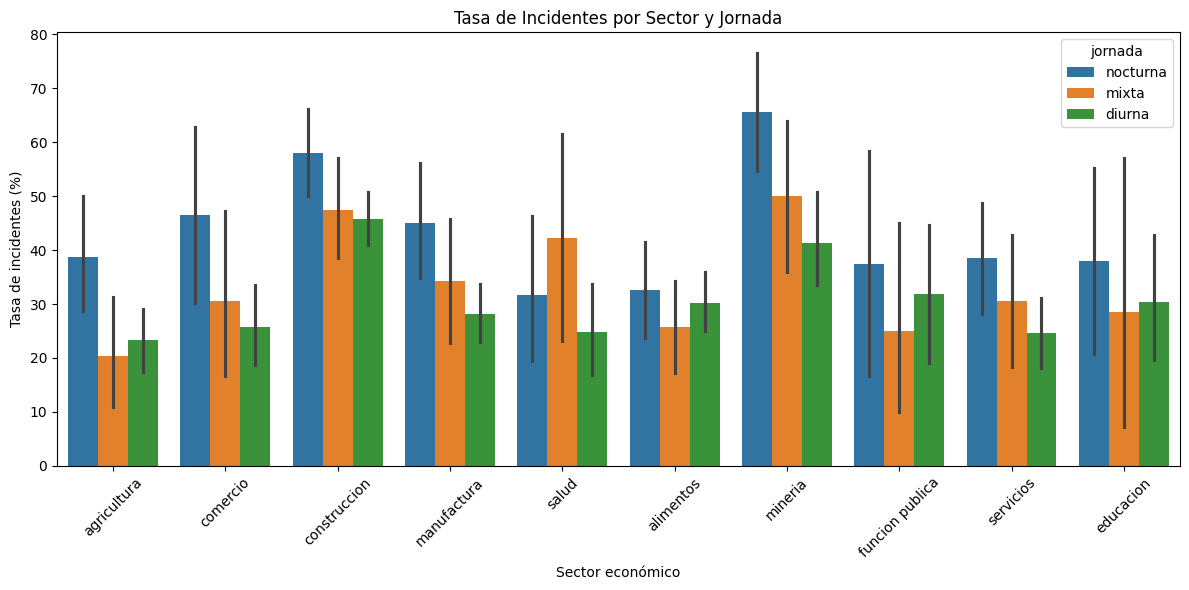

In [16]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df_final,
    x='sector_economico',
    y='incidente',
    hue='jornada',
    estimator=lambda x: sum(x)/len(x)*100
)

plt.title('Tasa de Incidentes por Sector y Jornada')
plt.xlabel('Sector económico')
plt.ylabel('Tasa de incidentes (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

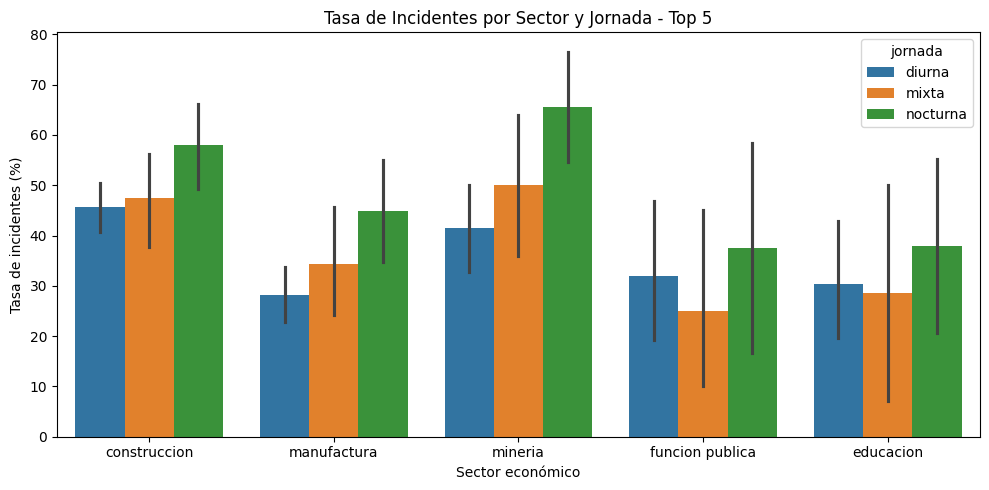

In [17]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_top5,
    x='sector_economico',
    y='incidente',
    hue='jornada',
    estimator=lambda x: sum(x)/len(x)*100
)

plt.title('Tasa de Incidentes por Sector y Jornada - Top 5')
plt.xlabel('Sector económico')
plt.ylabel('Tasa de incidentes (%)')
plt.tight_layout()
plt.show()

¿El sistema de gestión está asociado con menos incidentes dentro de los diferentes sectores?


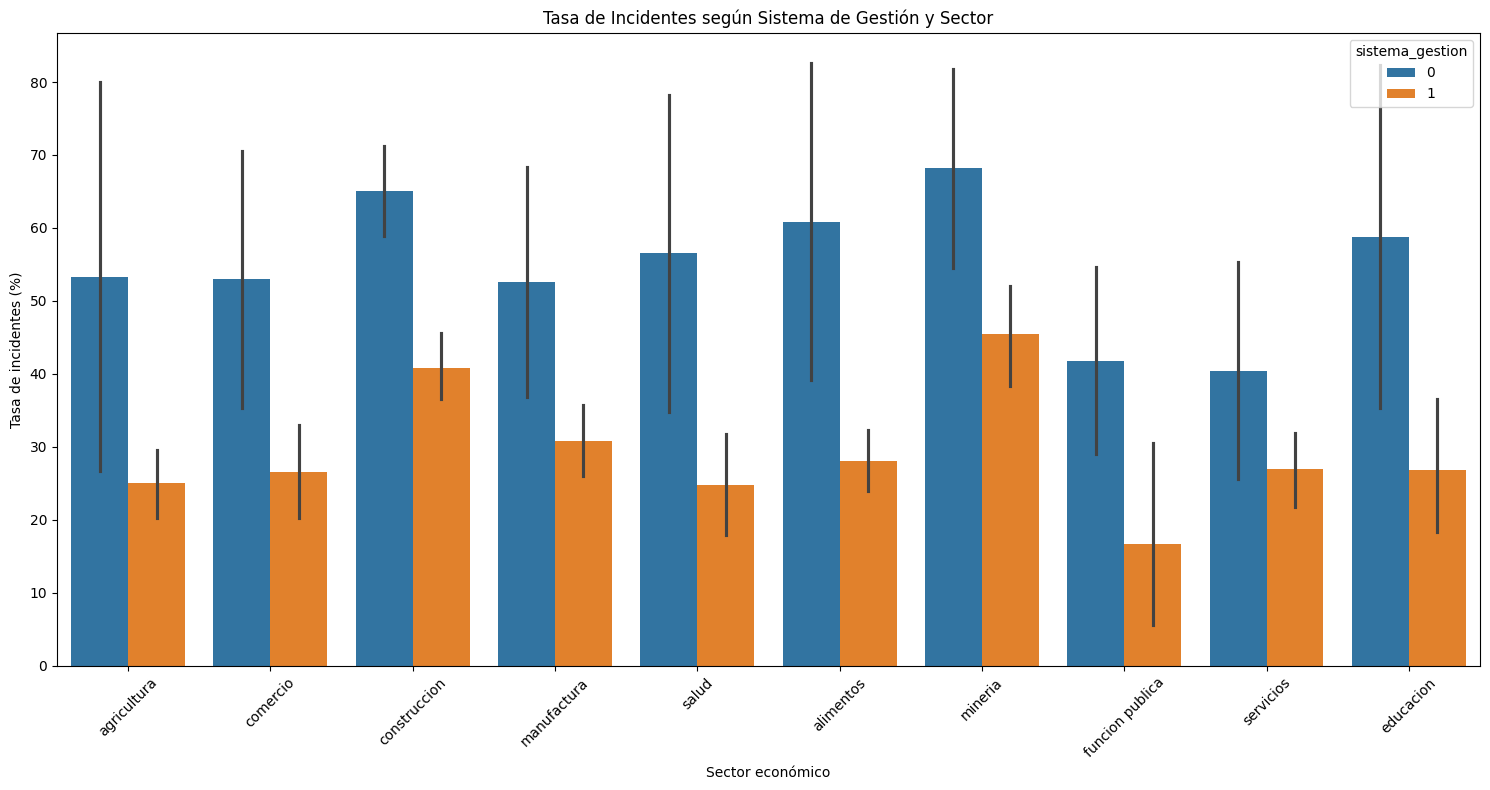

In [18]:
plt.figure(figsize=(15,8))

sns.barplot(
    data=df_final,
    x='sector_economico',
    y='incidente',
    hue='sistema_gestion',
    estimator=lambda x: sum(x)/len(x)*100
)

plt.title('Tasa de Incidentes según Sistema de Gestión y Sector')
plt.xlabel('Sector económico')
plt.ylabel('Tasa de incidentes (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

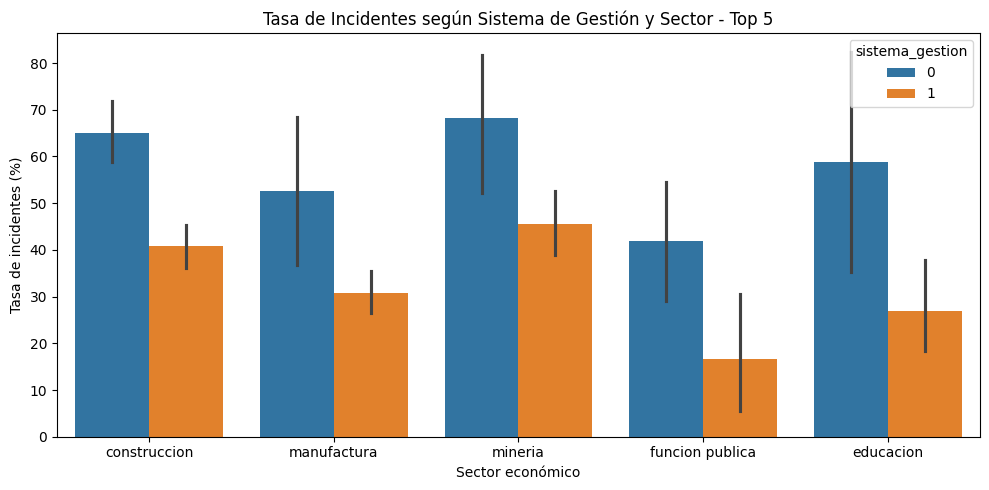

In [19]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_top5,
    x='sector_economico',
    y='incidente',
    hue='sistema_gestion',
    estimator=lambda x: sum(x)/len(x)*100
)

plt.title('Tasa de Incidentes según Sistema de Gestión y Sector - Top 5')
plt.xlabel('Sector económico')
plt.ylabel('Tasa de incidentes (%)')
plt.tight_layout()
plt.show()

¿Una empresa con sistema de gestión mantiene menores tasas de incidentes tanto en jornada diurna como nocturna?

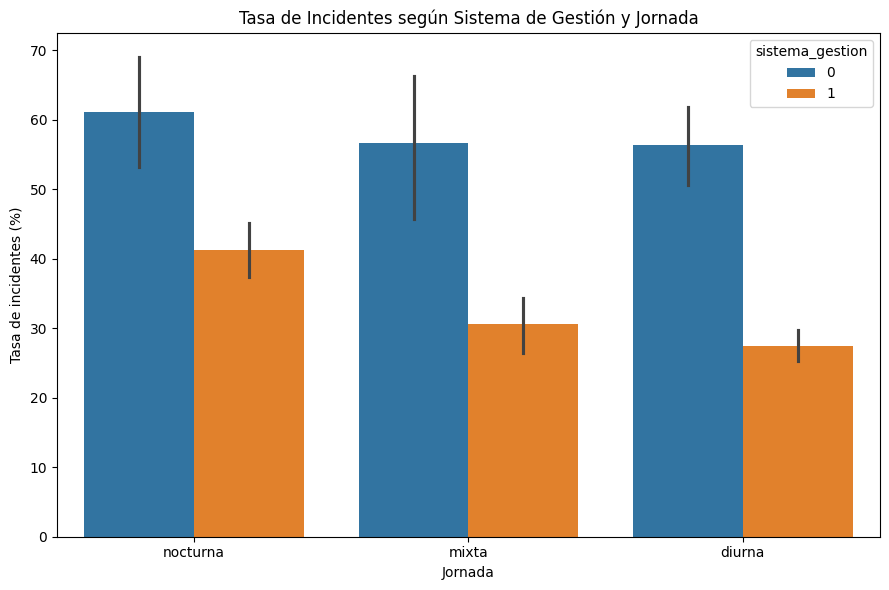

In [20]:
plt.figure(figsize=(9,6))

sns.barplot(
    data=df_final,
    x='jornada',
    y='incidente',
    hue='sistema_gestion',
    estimator=lambda x: sum(x)/len(x)*100
)

plt.title('Tasa de Incidentes según Sistema de Gestión y Jornada')
plt.xlabel('Jornada')
plt.ylabel('Tasa de incidentes (%)')

plt.tight_layout()
plt.show()

Estamos hablando de porcentajes, pero todavía no estamos viendo cuántos trabajadores hay detrás de cada porcentaje. ya que el porcentaje es exactamente el mismo, pero la evidencia no tiene la misma solidez.

JORNADA

In [21]:
resumen_jornada = (
    df_final.groupby('jornada')
    .agg(
        trabajadores=('id_trabajador', 'count'),
        incidentes=('incidente', 'sum'),
        tasa_incidentes=('incidente', 'mean')
    )
    .reset_index()
)

resumen_jornada['tasa_incidentes'] *= 100

resumen_jornada

,jornada,trabajadores,incidentes,tasa_incidentes
0,diurna,1767,570,32.258065
1,mixta,548,189,34.489051
2,nocturna,685,308,44.963504


CAPACITACIÓN

In [22]:
resumen_capacitacion = (
    df_final.groupby('capacitado')
    .agg(
        trabajadores=('id_trabajador', 'count'),
        incidentes=('incidente', 'sum'),
        tasa_incidentes=('incidente', 'mean')
    )
    .reset_index()
)

resumen_capacitacion['tasa_incidentes'] *= 100

resumen_capacitacion

,capacitado,trabajadores,incidentes,tasa_incidentes
0,0,1721,534,31.028472
1,1,1279,533,41.673182


SISTEMA DE GESTIÓN

In [23]:
resumen_gestion = (
    df_final.groupby('sistema_gestion')
    .agg(
        trabajadores=('id_trabajador', 'count'),
        incidentes=('incidente', 'sum'),
        tasa_incidentes=('incidente', 'mean')
    )
    .reset_index()
)

resumen_gestion['tasa_incidentes'] *= 100

resumen_gestion

,sistema_gestion,trabajadores,incidentes,tasa_incidentes
0,0,505,291,57.623762
1,1,2495,776,31.102204


MATRICES DE RIESGO

¿Cuál es la combinación sector + jornada de mayor riesgo?

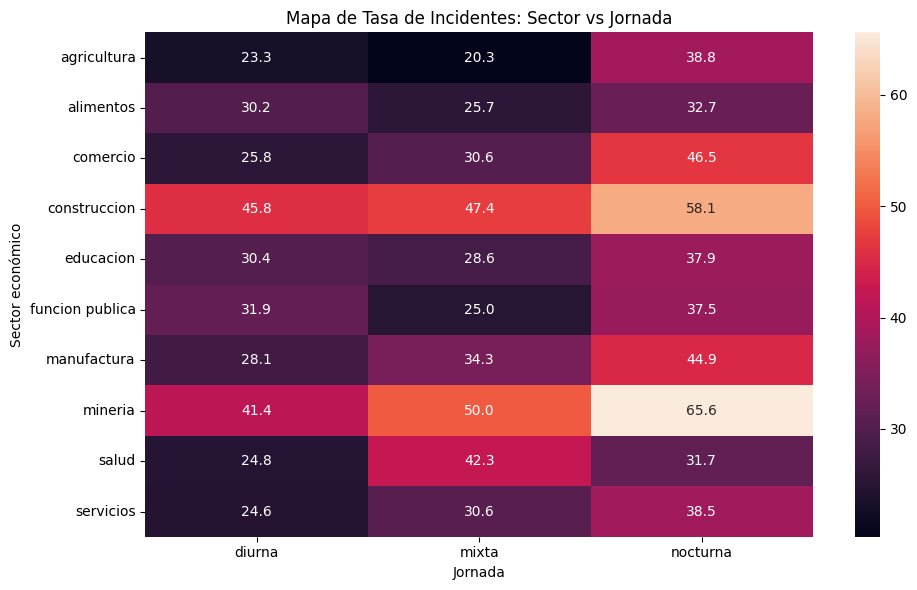

In [24]:
tabla_riesgo = pd.pivot_table(
    df_final,
    values='incidente',
    index='sector_economico',
    columns='jornada',
    aggfunc='mean'
) * 100

plt.figure(figsize=(10,6))

sns.heatmap(
    tabla_riesgo,
    annot=True,
    fmt='.1f'
)

plt.title('Mapa de Tasa de Incidentes: Sector vs Jornada')
plt.xlabel('Jornada')
plt.ylabel('Sector económico')

plt.tight_layout()
plt.show()

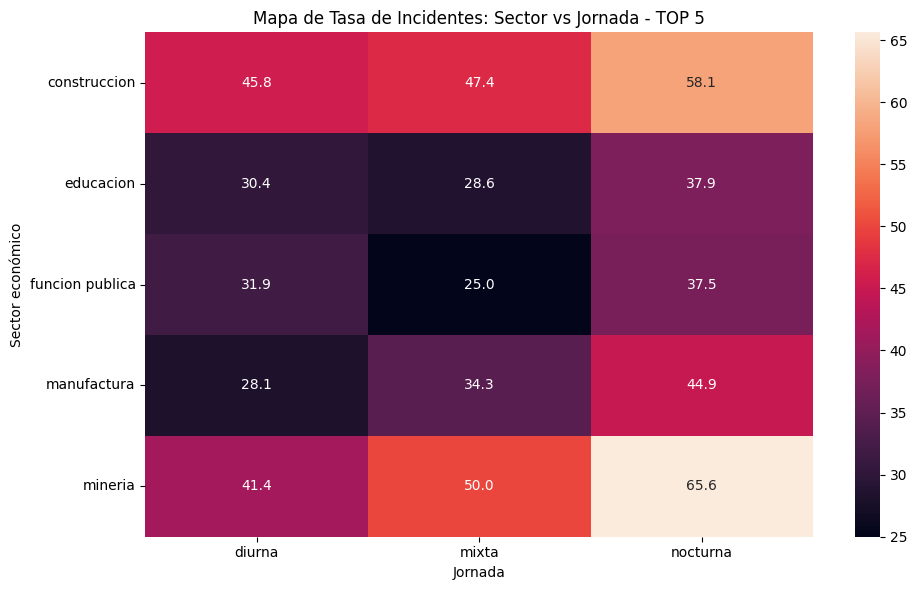

In [25]:
tabla_riesgo = pd.pivot_table(
    data=df_top5,
    values='incidente',
    index='sector_economico',
    columns='jornada',
    aggfunc='mean'
) * 100

plt.figure(figsize=(10,6))

sns.heatmap(
    tabla_riesgo,
    annot=True,
    fmt='.1f'
)

plt.title('Mapa de Tasa de Incidentes: Sector vs Jornada - TOP 5')
plt.xlabel('Jornada')
plt.ylabel('Sector económico')

plt.tight_layout()
plt.show()

¿Cuál es la combinación sector + capacitación de mayor riesgo?

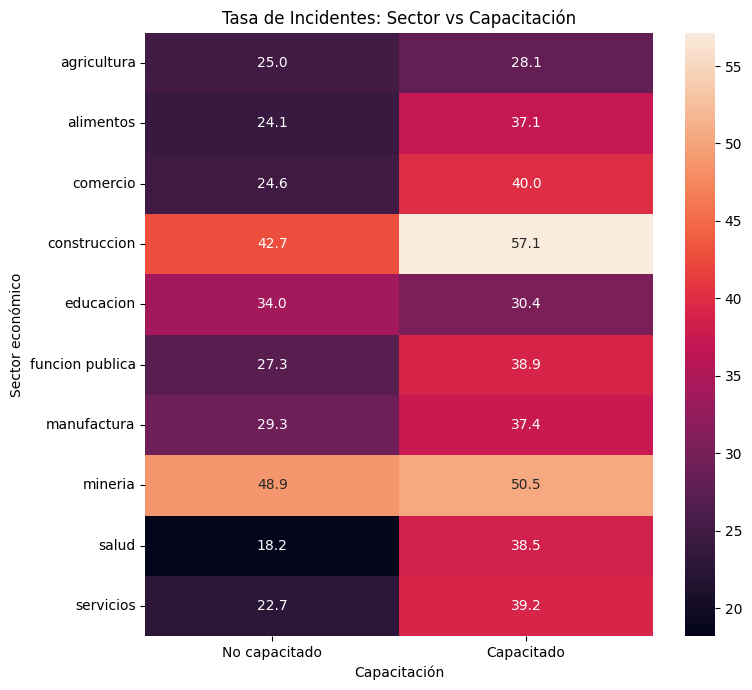

In [26]:
tabla_capacitacion = pd.pivot_table(
    df_final,
    values='incidente',
    index='sector_economico',
    columns='capacitado',
    aggfunc='mean'
) * 100

tabla_capacitacion.columns = ['No capacitado', 'Capacitado']

plt.figure(figsize=(8,7))

sns.heatmap(
    tabla_capacitacion,
    annot=True,
    fmt='.1f'
)

plt.title('Tasa de Incidentes: Sector vs Capacitación')
plt.xlabel('Capacitación')
plt.ylabel('Sector económico')

plt.tight_layout()
plt.show()

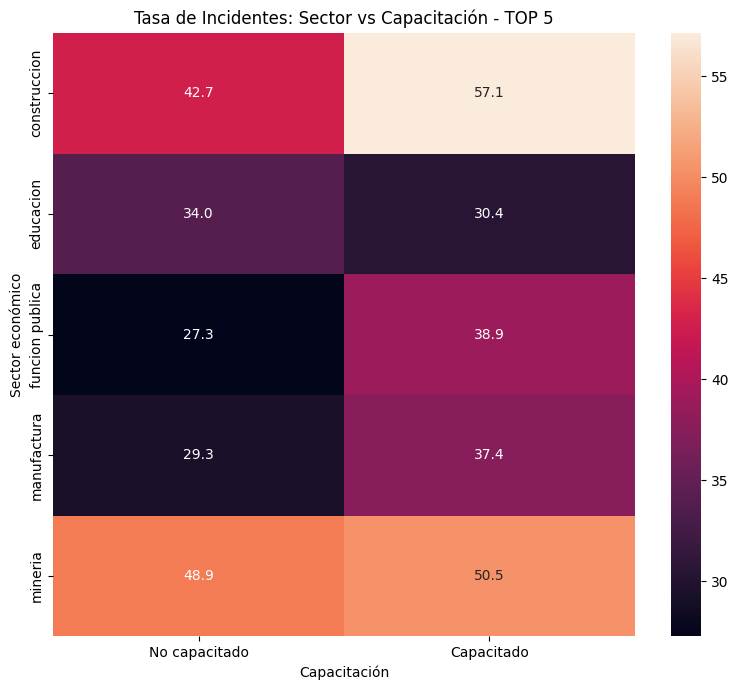

In [27]:
tabla_capacitacion = pd.pivot_table(
    data=df_top5,
    values='incidente',
    index='sector_economico',
    columns='capacitado',
    aggfunc='mean'
) * 100

tabla_capacitacion.columns = ['No capacitado', 'Capacitado']

plt.figure(figsize=(8,7))

sns.heatmap(
    tabla_capacitacion,
    annot=True,
    fmt='.1f'
)

plt.title('Tasa de Incidentes: Sector vs Capacitación - TOP 5')
plt.xlabel('Capacitación')
plt.ylabel('Sector económico')

plt.tight_layout()
plt.show()

¿Cuál es la combinación sector + sistema de gestion de mayor riesgo?

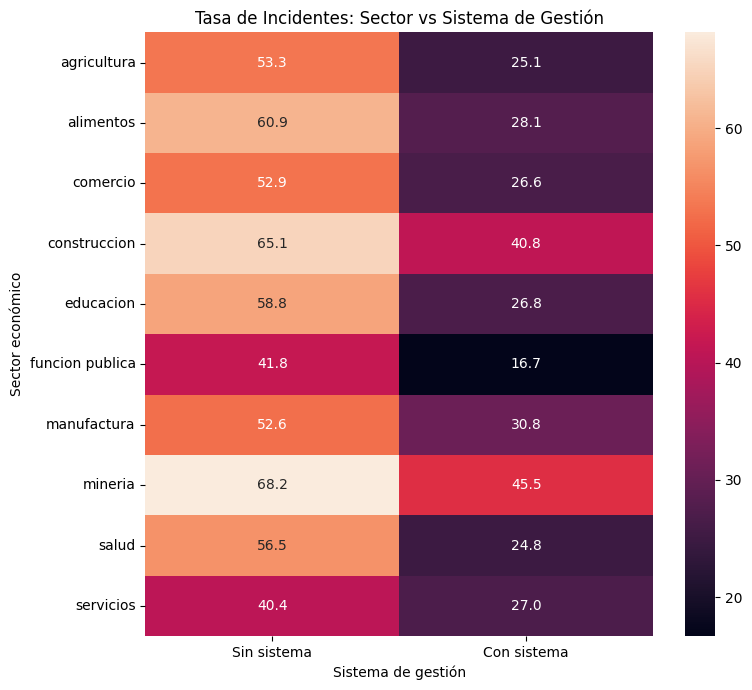

In [28]:
tabla_gestion = pd.pivot_table(
    df_final,
    values='incidente',
    index='sector_economico',
    columns='sistema_gestion',
    aggfunc='mean'
) * 100

tabla_gestion.columns = ['Sin sistema', 'Con sistema']

plt.figure(figsize=(8,7))

sns.heatmap(
    tabla_gestion,
    annot=True,
    fmt='.1f'
)

plt.title('Tasa de Incidentes: Sector vs Sistema de Gestión')
plt.xlabel('Sistema de gestión')
plt.ylabel('Sector económico')

plt.tight_layout()
plt.show()

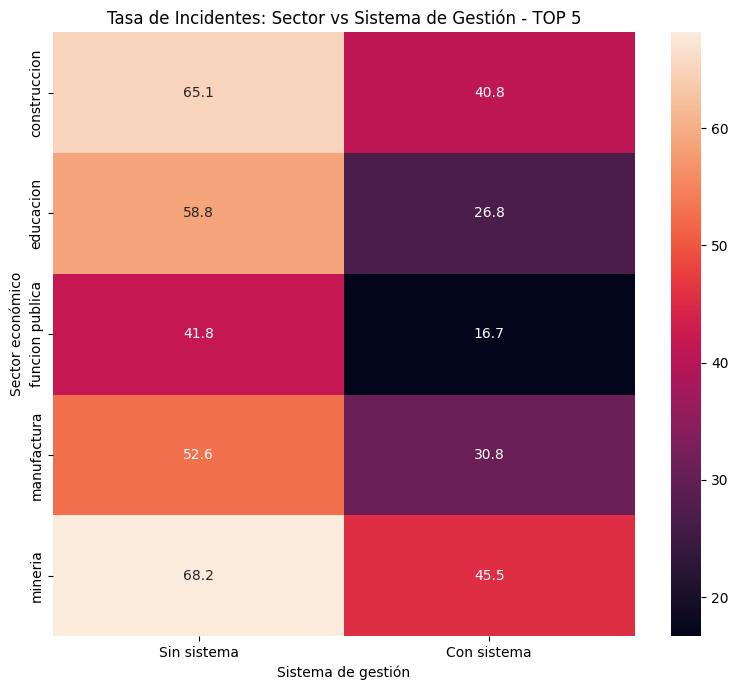

In [29]:
tabla_gestion = pd.pivot_table(
    data=df_top5,
    values='incidente',
    index='sector_economico',
    columns='sistema_gestion',
    aggfunc='mean'
) * 100

tabla_gestion.columns = ['Sin sistema', 'Con sistema']

plt.figure(figsize=(8,7))

sns.heatmap(
    tabla_gestion,
    annot=True,
    fmt='.1f'
)

plt.title('Tasa de Incidentes: Sector vs Sistema de Gestión - TOP 5')
plt.xlabel('Sistema de gestión')
plt.ylabel('Sector económico')

plt.tight_layout()
plt.show()

ITERACIÓN 3

¿Cuántos registros tiene cada fuente?

In [30]:
print("=== TAMAÑO DE LAS FUENTES ===")

print("Trabajadores:", df_trabajadores.shape)
print("Empresas:", df_empresas.shape)
print("Accidentes:", df_accidentes.shape)

print("\n=== REGISTROS ===")
print("Trabajadores:", len(df_trabajadores))
print("Empresas:", len(df_empresas))
print("Accidentes:", len(df_accidentes))

=== TAMAÑO DE LAS FUENTES ===
Trabajadores: (3000, 11)
Empresas: (150, 5)
Accidentes: (1067, 5)

=== REGISTROS ===
Trabajadores: 3000
Empresas: 150
Accidentes: 1067


¿Cada trabajador aparece una sola vez?

In [31]:
print("=== UNICIDAD DE TRABAJADORES ===")

print("Trabajadores totales:", len(df_trabajadores))
print("IDs de trabajador únicos:", df_trabajadores['id_trabajador'].nunique())

duplicados_trabajadores = (
    df_trabajadores['id_trabajador']
    .duplicated()
    .sum()
)

print("IDs de trabajador duplicados:", duplicados_trabajadores)

=== UNICIDAD DE TRABAJADORES ===
Trabajadores totales: 3000
IDs de trabajador únicos: 3000
IDs de trabajador duplicados: 0


¿Cada trabajador tiene cero o un accidente, o puede tener varios?

In [32]:
print("=== ACCIDENTES POR TRABAJADOR ===")

accidentes_por_trabajador = (
    df_accidentes
    .groupby('id_trabajador')
    .size()
    .value_counts()
    .sort_index()
)

print(accidentes_por_trabajador)

=== ACCIDENTES POR TRABAJADOR ===
1    1067
Name: count, dtype: int64


¿El Triple Join conservó correctamente los trabajadores?

In [33]:
print("=== DISTRIBUCIÓN DEL INCIDENTE ===")

print(df_final['incidente'].value_counts())

print("\nPorcentaje:")
print(df_final['incidente'].value_counts(normalize=True) * 100)

=== DISTRIBUCIÓN DEL INCIDENTE ===
incidente
0    1933
1    1067
Name: count, dtype: int64

Porcentaje:
incidente
0    64.433333
1    35.566667
Name: proportion, dtype: float64


¿Hay valores faltantes o categorías extrañas?

In [34]:
print("=== VALIDACIÓN DEL TRIPLE JOIN ===")

print("Trabajadores originales:", len(df_trabajadores))
print("Registros después del join:", len(df_final))

print(
    "Trabajadores únicos después del join:",
    df_final['id_trabajador'].nunique()
)

=== VALIDACIÓN DEL TRIPLE JOIN ===
Trabajadores originales: 3000
Registros después del join: 3000
Trabajadores únicos después del join: 3000


¿Cómo está distribuida realmente nuestra población?

In [35]:
df_merge = pd.merge(
    df_trabajadores,
    df_empresas,
    left_on='empresa',
    right_on='id_empresa'
)

In [36]:
print("=== RELACIÓN TRABAJADOR - EMPRESA ===")

print("Trabajadores:", len(df_trabajadores))
print("Trabajadores después de unir empresa:", len(df_merge))

print(
    "Trabajadores únicos después de unir empresa:",
    df_merge['id_trabajador'].nunique()
)

print(
    "Trabajadores sin empresa:",
    df_merge['id_empresa'].isna().sum()
)

=== RELACIÓN TRABAJADOR - EMPRESA ===
Trabajadores: 3000
Trabajadores después de unir empresa: 3000
Trabajadores únicos después de unir empresa: 3000
Trabajadores sin empresa: 0


REVISIONES

Valores Faltantes

In [37]:
print("=== VALORES FALTANTES EN df_final ===")

faltantes = (
    df_final.isna()
    .sum()
    .sort_values(ascending=False)
)

print(faltantes)

=== VALORES FALTANTES EN df_final ===
lesion              1933
parte_del_cuerpo    1933
id_accidente        1933
Unnamed: 0          1933
rango_antiguedad      22
Unnamed: 0_x           0
num_hijos              0
nivel_educativo        0
genero                 0
edad                   0
id_trabajador          0
tipo_cargo             0
jornada                0
capacitado             0
sector_economico       0
id_empresa             0
Unnamed: 0_y           0
empresa                0
antiguedad             0
sistema_gestion        0
tipo_empresa           0
incidente              0
dtype: int64


Categorias

In [38]:
print("=== CATEGORÍAS ===")

print("\nJornada:")
print(df_final['jornada'].value_counts(dropna=False))

print("\nCapacitado:")
print(df_final['capacitado'].value_counts(dropna=False))

print("\nSistema de gestión:")
print(df_final['sistema_gestion'].value_counts(dropna=False))

print("\nNivel educativo:")
print(df_final['nivel_educativo'].value_counts(dropna=False))

print("\nSector económico:")
print(df_final['sector_economico'].value_counts(dropna=False))

=== CATEGORÍAS ===

Jornada:
jornada
diurna      1767
nocturna     685
mixta        548
Name: count, dtype: int64

Capacitado:
capacitado
0    1721
1    1279
Name: count, dtype: int64

Sistema de gestión:
sistema_gestion
1    2495
0     505
Name: count, dtype: int64

Nivel educativo:
nivel_educativo
tecnico            1472
bachiller          1033
universitario       354
especializacion      77
maestria             64
Name: count, dtype: int64

Sector económico:
sector_economico
construccion       650
alimentos          471
manufactura        408
agricultura        350
servicios          314
mineria            242
comercio           207
salud              168
educacion           99
funcion publica     91
Name: count, dtype: int64


In [39]:
print(df_final.groupby('sistema_gestion')['incidente'].agg(
    ['count', 'sum', 'mean']
))

                 count  sum      mean
sistema_gestion                      
0                  505  291  0.576238
1                 2495  776  0.311022


¿Cuantos trabajadores hay en cada sector?


In [40]:
resumen_sector = (
    df_final.groupby('sector_economico')
    .agg(
        trabajadores=('id_trabajador', 'count'),
        incidentes=('incidente', 'sum'),
        tasa_incidentes=('incidente', 'mean')
    )
    .sort_values('tasa_incidentes', ascending=False)
    .reset_index()
)

resumen_sector['tasa_incidentes'] *= 100

resumen_sector

,sector_economico,trabajadores,incidentes,tasa_incidentes
0,mineria,242,120,49.586777
1,construccion,650,316,48.615385
2,manufactura,408,134,32.843137
3,educacion,99,32,32.323232
4,funcion publica,91,29,31.868132
5,comercio,207,64,30.917874
6,alimentos,471,140,29.723992
7,salud,168,49,29.166667
8,servicios,314,91,28.980892
9,agricultura,350,92,26.285714


Combinaciones de Mayor Riesgo

Sector X Jornada

In [41]:
resumen_sector_jornada = (
    df_final.groupby(['sector_economico', 'jornada'])
    .agg(
        trabajadores=('id_trabajador', 'count'),
        incidentes=('incidente', 'sum'),
        tasa_incidentes=('incidente', 'mean')
    )
    .reset_index()
)

resumen_sector_jornada['tasa_incidentes'] *= 100

resumen_sector_jornada = resumen_sector_jornada.sort_values(
    'tasa_incidentes',
    ascending=False
)

resumen_sector_jornada

,sector_economico,jornada,trabajadores,incidentes,tasa_incidentes
23,mineria,nocturna,64,42,65.625000
11,construccion,nocturna,136,79,58.088235
22,mineria,mixta,50,25,50.000000
10,construccion,mixta,114,54,47.368421
8,comercio,nocturna,43,20,46.511628
9,construccion,diurna,400,183,45.750000
20,manufactura,nocturna,89,40,44.943820
25,salud,mixta,26,11,42.307692
21,mineria,diurna,128,53,41.406250
2,agricultura,nocturna,80,31,38.750000


Sector X Gestión

In [42]:
resumen_sector_gestion = (
    df_final.groupby(['sector_economico', 'sistema_gestion'])
    .agg(
        trabajadores=('id_trabajador', 'count'),
        incidentes=('incidente', 'sum'),
        tasa_incidentes=('incidente', 'mean')
    )
    .reset_index()
)

resumen_sector_gestion['tasa_incidentes'] *= 100

resumen_sector_gestion = resumen_sector_gestion.sort_values(
    'tasa_incidentes',
    ascending=False
)

resumen_sector_gestion

,sector_economico,sistema_gestion,trabajadores,incidentes,tasa_incidentes
14,mineria,0,44,30,68.181818
6,construccion,0,209,136,65.071770
2,alimentos,0,23,14,60.869565
8,educacion,0,17,10,58.823529
16,salud,0,23,13,56.521739
0,agricultura,0,15,8,53.333333
4,comercio,0,34,18,52.941176
12,manufactura,0,38,20,52.631579
15,mineria,1,198,90,45.454545
10,funcion publica,0,55,23,41.818182


Sector X Capaitación

In [43]:
resumen_sector_capacitacion = (
    df_final.groupby(['sector_economico', 'capacitado'])
    .agg(
        trabajadores=('id_trabajador', 'count'),
        incidentes=('incidente', 'sum'),
        tasa_incidentes=('incidente', 'mean')
    )
    .reset_index()
)

resumen_sector_capacitacion['tasa_incidentes'] *= 100

resumen_sector_capacitacion = resumen_sector_capacitacion.sort_values(
    'tasa_incidentes',
    ascending=False
)

resumen_sector_capacitacion

,sector_economico,capacitado,trabajadores,incidentes,tasa_incidentes
7,construccion,1,266,152,57.142857
15,mineria,1,105,53,50.476190
14,mineria,0,137,67,48.905109
6,construccion,0,384,164,42.708333
5,comercio,1,85,34,40.000000
19,servicios,1,120,47,39.166667
11,funcion publica,1,36,14,38.888889
17,salud,1,91,35,38.461538
13,manufactura,1,179,67,37.430168
3,alimentos,1,205,76,37.073171


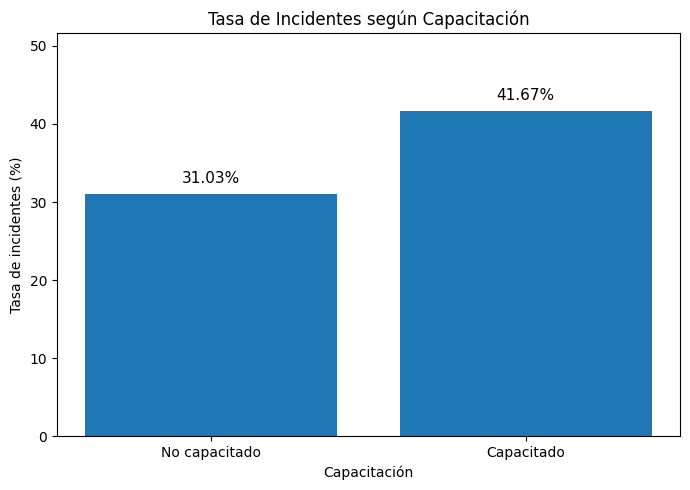

    capacitacion  trabajadores  incidentes  tasa_incidentes
0  No capacitado          1721         534        31.028472
1     Capacitado          1279         533        41.673182


In [47]:
# ============================================
# TASA DE INCIDENTES SEGÚN CAPACITACIÓN
# ============================================

import matplotlib.pyplot as plt

# Calcular trabajadores, incidentes y tasa
resumen_capacitacion = (
    df_final.groupby('capacitado')
    .agg(
        trabajadores=('id_trabajador', 'count'),
        incidentes=('incidente', 'sum'),
        tasa_incidentes=('incidente', 'mean')
    )
    .reset_index()
)

# Convertir la tasa a porcentaje
resumen_capacitacion['tasa_incidentes'] *= 100

# Etiquetas
resumen_capacitacion['capacitacion'] = resumen_capacitacion['capacitado'].map({
    0: 'No capacitado',
    1: 'Capacitado'
})

# Gráfico
plt.figure(figsize=(7, 5))

barras = plt.bar(
    resumen_capacitacion['capacitacion'],
    resumen_capacitacion['tasa_incidentes']
)

# Mostrar porcentaje encima de cada barra
for barra, valor in zip(barras, resumen_capacitacion['tasa_incidentes']):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 1,
        f'{valor:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title('Tasa de Incidentes según Capacitación')
plt.xlabel('Capacitación')
plt.ylabel('Tasa de incidentes (%)')
plt.ylim(0, max(resumen_capacitacion['tasa_incidentes']) + 10)

plt.tight_layout()
plt.show()

# Mostrar tabla de respaldo
print(resumen_capacitacion[
    ['capacitacion', 'trabajadores', 'incidentes', 'tasa_incidentes']
])

## Conclusiones

1. La jornada nocturna se identifica como un factor asociado a una mayor tasa de incidentes. Presenta una tasa de 44,96 %, frente al 32,26 % de la jornada diurna, y mantiene la mayor tasa en la mayoría de las combinaciones sectoriales analizadas. El riesgo es especialmente crítico en minería nocturna (65,63 %) y construcción nocturna (58,09 %), por lo que estos segmentos deberían recibir prioridad en las estrategias preventivas (siendo mayor al 35,57 % de tasa global de incidentes).

2. La capacitación, en su forma binaria actual (capacitado/no capacitado), no presenta una asociación descriptiva con menor tasa de incidentes. El grupo capacitado presenta 41,67 % frente a 31,03 % en el grupo no capacitado. Sin embargo, estos resultados no permiten concluir que la capacitación sea ineficaz o que incremente el riesgo, debido a que no se dispone de información suficiente sobre el tipo, calidad, momento, frecuencia y población objetivo de la capacitación.

3. La asociación entre la presencia de un sistema de gestión y una menor tasa de incidentes es consistente en el análisis descriptivo y constituye el hallazgo más fuerte para orientar una intervención empresarial. Las empresas con sistema de gestión presentan menor tasa de incidentes en los datos analizados.



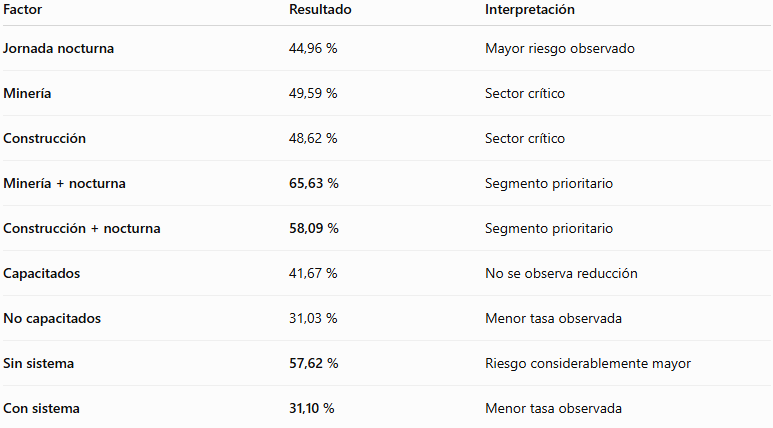

El análisis evidencia que el riesgo laboral no se distribuye de manera homogénea entre los trabajadores. La jornada nocturna presenta la mayor tasa de incidentes (44,96 %), con concentraciones especialmente críticas en minería nocturna (65,63 %) y construcción nocturna (58,09 %). Por otra parte, la condición de estar capacitado no muestra una reducción descriptiva de los incidentes, ya que los trabajadores capacitados presentan 41,67 % frente a 31,03 % de los no capacitados; este resultado debe interpretarse con cautela debido a la ausencia de información sobre el tipo, momento y población objetivo de la capacitación. Finalmente, las empresas con sistema de gestión presentan una tasa de incidentes de 31,10 %, frente a 57,62 % en aquellas sin sistema, constituyendo la asociación más fuerte encontrada y un punto prioritario para la gestión preventiva.

Con la información obtenido, podemos contestar las siguientes preguntas

¿Influye la jornada (diurna/nocturna)?

Sí, encontramos una asociación consistente.

¿Sirve realmente la
capacitación para prevenir accidentes?

No observamos una reducción, pero no podemos establecer causalidad.

¿Las empresas con sistema de gestión tienen efectivamente menos
accidentes?

Sí encontramos una asociación fuerte con menores tasas, consistente con las segmentaciones realizadas.

REGLA DE ALERTA PREVENTIVA

Si un trabajador pertenece a un sector de alto riesgo (minería o construcción) y trabaja en jornada nocturna, el ERP debe clasificarlo como "Riesgo Alto" y generar una alerta preventiva.
Si además la empresa no cuenta con sistema de gestión, elevar la clasificación a "Riesgo Crítico" y generar una acción prioritaria de intervención.